In [1]:
import MetaTrader5 as mt5
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import talib as ta

import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt



pd.options.mode.chained_assignment = None

In [2]:
#Hidden as temp
account = 5047043720
password = "MbJtC_0o"

#Connect MetaTrader
def connect(account):
    mt5.initialize()
    authorized = mt5.login(account, password=password, server="MetaQuotes-Demo")
    if not authorized:
        raise RuntimeError(mt5.last_error())
    print("Connected")

connect(account)

Connected


In [3]:
# =========================
# Symbol selection
# =========================
trade_type = "XAUUSD"
#trade_type = "HSI50"
#trade_type = "GBPJPY"
#trade_type = "EURNZD"

# =========================
# Parameters
# =========================
next_min_value = 240
next_max_value = 240

# =========================
# Date ranges
# =========================
from_hour = datetime(2010, 1, 1)
to_hour   = datetime(2021, 3, 31)

from_day  = datetime(2008, 1, 1)
to_day    = datetime(2021, 12, 31)

from_week = datetime(2008, 10, 7)
to_week   = datetime(2022, 2, 1)

# =========================
# Data extraction
# =========================
rates_hour = mt5.copy_rates_range(trade_type, mt5.TIMEFRAME_H1, from_hour, to_hour)
rates_day  = mt5.copy_rates_range(trade_type, mt5.TIMEFRAME_D1, from_day, to_day)
rates_week = mt5.copy_rates_range(trade_type, mt5.TIMEFRAME_W1, from_week, to_week)

def prepare_df(rates):
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    return df.drop(columns=['real_volume', 'spread'])

df_hour = prepare_df(rates_hour)
df_day  = prepare_df(rates_day)
df_week = prepare_df(rates_week)

# =========================
# Moving averages (H1-based)
# =========================
df_hour['MA_5min']  = round(ta.SMA(df_hour['close'], int(50 / 12)), 2)
df_hour['MA_hour']  = round(ta.SMA(df_hour['close'], 50), 2)
df_hour['MA_day']   = round(ta.SMA(df_hour['close'], 50 * 24), 2)
df_hour['MA_week']  = round(ta.SMA(df_hour['close'], 50 * 24 * 7), 2)

df_hour = df_hour.drop(columns=['tick_volume'])

# =========================
# Reverse time (future → past)
# =========================
df_reverse = df_hour[['time', 'open', 'close', 'low', 'high']].iloc[::-1].reset_index(drop=True)

# =========================
# Future min / max (renamed immediately)
# =========================
df_reverse['low_for_next']  = df_reverse['low']
df_reverse['high_for_next'] = df_reverse['high']

df_reverse['next_min'] = df_reverse['low_for_next'].rolling(next_min_value).min().shift()
df_reverse['next_max'] = df_reverse['high_for_next'].rolling(next_max_value).max().shift()

# =========================
# Deduplicate future extremes
# =========================
df_min = df_reverse.drop_duplicates(subset=['next_min'], keep='last')
df_min = df_min.rename(columns={
    'time': 'next_min_time',
    'next_min': 'next_min_unique'
})

df_max = df_reverse.drop_duplicates(subset=['next_max'], keep='last')
df_max = df_max.rename(columns={
    'time': 'next_max_time',
    'next_max': 'next_max_unique'
})

df_min = df_min.iloc[::-1].reset_index(drop=True)
df_max = df_max.iloc[::-1].reset_index(drop=True)

# =========================
# Final merged table
# =========================
df_hour_nextminmax = pd.concat(
    [
        df_hour.reset_index(drop=True),
        df_reverse['next_min'].iloc[::-1].reset_index(drop=True),
        df_reverse['next_max'].iloc[::-1].reset_index(drop=True),
        df_min['next_min_unique'],
        df_max['next_max_unique'],
        df_min['next_min_time'],
        df_max['next_max_time']
    ],
    axis=1
)

# Fill missing timestamps
df_hour_nextminmax['next_min_time'] = df_hour_nextminmax['next_min_time'].bfill()
df_hour_nextminmax['next_max_time'] = df_hour_nextminmax['next_max_time'].bfill()

display(df_hour_nextminmax)

,time,open,high,low,close,MA_5min,MA_hour,MA_day,MA_week,next_min,next_max,next_min_unique,next_max_unique,next_min_time,next_max_time
0,2009-12-31 16:00:00,1099.20,1100.65,1095.85,1098.03,NaN,NaN,NaN,NaN,1093.08,1161.63,1093.08,1161.63,2009-12-31 16:00:00,2009-12-31 16:00:00
1,2009-12-31 17:00:00,1098.01,1098.30,1094.20,1096.40,NaN,NaN,NaN,NaN,1093.08,1161.63,1094.00,1160.54,2010-01-04 01:00:00,2010-01-11 14:00:00
2,2009-12-31 18:00:00,1096.45,1098.71,1095.35,1098.30,NaN,NaN,NaN,NaN,1093.08,1161.63,1095.28,1158.60,2010-01-04 02:00:00,2010-01-11 15:00:00
3,2010-01-04 01:00:00,1094.61,1096.90,1093.08,1094.49,1096.80,NaN,NaN,NaN,1094.00,1161.63,1096.95,1158.03,2010-01-04 03:00:00,2010-01-11 16:00:00
4,2010-01-04 02:00:00,1094.95,1095.95,1094.00,1095.65,1096.21,NaN,NaN,NaN,1095.28,1161.63,1098.52,1157.37,2010-01-04 04:00:00,2010-01-12 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65603,2021-03-30 12:00:00,1698.09,1700.95,1696.04,1696.19,1698.72,1720.49,1783.61,1738.93,NaN,NaN,NaN,NaN,NaT,NaT
65604,2021-03-30 13:00:00,1696.20,1696.70,1692.89,1693.22,1696.23,1719.80,1783.49,1738.96,NaN,NaN,NaN,NaN,NaT,NaT
65605,2021-03-30 14:00:00,1693.17,1693.61,1686.24,1688.33,1693.96,1719.01,1783.35,1738.98,NaN,NaN,NaN,NaN,NaT,NaT
65606,2021-03-30 15:00:00,1688.32,1690.46,1678.77,1683.79,1690.38,1718.13,1783.21,1739.00,NaN,NaN,NaN,NaN,NaT,NaT


In [4]:
# =========================
# Stochastic Oscillator
# =========================
def calculate_stochastic_oscillator(df, k_period, d_period, slowing):
    close = price_series(df, 'close')
    low   = price_series(df, 'low')
    high  = price_series(df, 'high')

    low_min = low.rolling(k_period).min()
    high_max = high.rolling(k_period).max()

    df['%K'] = (close - low_min) / (high_max - low_min) * 100
    df['%D'] = df['%K'].rolling(d_period).mean()
    df['%DSlow'] = df['%D'].rolling(slowing).mean()

    return df

def price_series(df, column):
    """
    Safely return a single Series even if duplicate columns exist.
    """
    col = df.loc[:, column]
    return col.iloc[:, 0] if isinstance(col, pd.DataFrame) else col

# =========================
# Apply indicators
# =========================
df_full = df_hour_nextminmax.copy()

df_full = calculate_stochastic_oscillator(
    df_full,
    k_period=12,
    d_period=12,
    slowing=8
)

# =========================
# Trend-following breakout strength
# =========================
lookback_breakout = 72  # ~3 days of hourly candles

rolling_high = df_full['high'].rolling(lookback_breakout).max().shift()
rolling_low  = df_full['low'].rolling(lookback_breakout).min().shift()

# Continuous measure: 0 = at recent low, 1 = at recent high
df_full['breakout_strength'] = (df_full['close'] - rolling_low) / (rolling_high - rolling_low)

# Optional: cap values to 0-1 (sometimes close slightly outside due to gaps)
df_full['breakout_strength'] = df_full['breakout_strength'].clip(0,1)

# Categorical filter for strategy
df_full['trend_label'] = pd.cut(
    df_full['breakout_strength'],
    bins=[-0.01, 0.1, 0.9, 1.01],  # small tolerance outside 0-1
    labels=['low', 'neutral', 'high']
)

df_full['cs_color'] = np.where(
    df_full['close'] > df_full['open'], 'green',
    np.where(df_full['close'] < df_full['open'], 'red', 'neutral')
)

# Now you have both:
# - breakout_strength → continuous numeric measure for analysis or machine learning
# - trend_label → categorical filter for trend-following strategy

# =========================
# Sentinel fill (temporary)
# =========================
SENTINEL_LOW = -999999
SENTINEL_HIGH = 999999

# =========================
# BUY candidates
# =========================
df_full_filled = df_full.copy()

numeric_cols = df_full_filled.select_dtypes(include=[np.number]).columns
df_full_filled[numeric_cols] = df_full_filled[numeric_cols].fillna(SENTINEL_LOW)

buy_df = df_full_filled.loc[
    (df_full_filled['close'] > df_full_filled['MA_5min']) &
    (df_full_filled['close'] > df_full_filled['MA_hour'])
].copy()

buy_df['close'] = buy_df['close'].round(2)
buy_df['position_type'] = 'buy_position'

buy_df = buy_df.replace(SENTINEL_LOW, np.nan)
buy_df = buy_df.reset_index(drop=True)

buy_df['Result'] = 0
buy_df['time'] = pd.to_datetime(buy_df['time'])

# Session filter (06:00–16:00)
buy_df = buy_df[
    (buy_df['time'].dt.hour >= 6) &
    (buy_df['time'].dt.hour <= 16)
]

# =========================
# SELL candidates
# =========================
df_full_filled = df_full.copy()

numeric_cols = df_full_filled.select_dtypes(include=[np.number]).columns
df_full_filled[numeric_cols] = df_full_filled[numeric_cols].replace(SENTINEL_LOW, SENTINEL_HIGH)

sell_df = df_full_filled.loc[
    (df_full_filled['close'] < df_full_filled['MA_5min']) &
    (df_full_filled['close'] < df_full_filled['MA_hour'])
].copy()

sell_df['close'] = sell_df['close'].round(2)
sell_df['position_type'] = 'sell_position'

sell_df = sell_df.replace(SENTINEL_HIGH, np.nan)
sell_df = sell_df.reset_index(drop=True)

sell_df['Result'] = 0
sell_df['time'] = pd.to_datetime(sell_df['time'])

# Session filter (06:00–16:00)
sell_df = sell_df[
    (sell_df['time'].dt.hour >= 6) &
    (sell_df['time'].dt.hour <= 16)
]

# =========================
# Globals (unchanged behavior)
# =========================
global buy_df
global sell_df

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_full.to_clipboard(index=False)

display(buy_df)

,time,open,high,low,close,MA_5min,MA_hour,MA_day,MA_week,next_min,next_max,next_min_unique,next_max_unique,next_min_time,next_max_time,%K,%D,%DSlow,breakout_strength,trend_label,cs_color,position_type,Result
0,2009-12-31 16:00:00,1099.20,1100.65,1095.85,1098.03,NaN,NaN,NaN,NaN,1093.08,1161.63,1093.08,1161.63,2009-12-31 16:00:00,2009-12-31 16:00:00,NaN,NaN,NaN,NaN,NaN,red,buy_position,0
6,2010-01-04 06:00:00,1101.20,1103.90,1101.15,1102.85,1100.30,NaN,NaN,NaN,1100.35,1161.63,1112.35,1148.17,2010-01-04 10:00:00,2010-01-12 17:00:00,NaN,NaN,NaN,NaN,NaN,green,buy_position,0
7,2010-01-04 07:00:00,1102.80,1104.15,1101.90,1102.85,1101.55,NaN,NaN,NaN,1100.35,1161.63,1113.00,1145.99,2010-01-04 11:00:00,2010-01-12 18:00:00,NaN,NaN,NaN,NaN,NaN,green,buy_position,0
8,2010-01-04 08:00:00,1102.75,1104.00,1100.35,1103.85,1102.79,NaN,NaN,NaN,1103.80,1161.63,1114.10,1145.83,2010-01-04 12:00:00,2010-01-14 19:00:00,NaN,NaN,NaN,NaN,NaN,green,buy_position,0
9,2010-01-04 09:00:00,1103.90,1111.20,1103.80,1109.95,1104.88,NaN,NaN,NaN,1109.50,1161.63,1115.40,1145.63,2010-01-04 14:00:00,2010-01-14 20:00:00,93.101545,NaN,NaN,NaN,NaN,green,buy_position,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20493,2021-03-24 11:00:00,1731.05,1734.91,1730.68,1734.65,1731.40,1733.80,1793.08,1736.35,NaN,NaN,NaN,NaN,NaT,NaT,97.661871,56.698666,39.561717,0.473615,neutral,green,buy_position,0
20501,2021-03-25 06:00:00,1735.30,1735.96,1734.02,1735.75,1734.83,1732.90,1791.45,1736.86,NaN,NaN,NaN,NaN,NaT,NaT,52.674897,58.254123,59.302570,0.619689,neutral,green,buy_position,0
20502,2021-03-25 15:00:00,1729.80,1745.43,1728.60,1738.88,1732.16,1732.17,1790.59,1737.12,NaN,NaN,NaN,NaN,NaT,NaT,67.986315,35.140002,41.597523,0.802233,neutral,green,buy_position,0
20503,2021-03-25 16:00:00,1738.89,1741.12,1733.17,1736.91,1733.53,1732.10,1790.50,1737.15,NaN,NaN,NaN,NaN,NaT,NaT,58.357771,34.395287,39.426767,0.606285,neutral,red,buy_position,0


In [5]:
# =========================
# Column reference / purpose
# =========================
# time               : Timestamp of the candle (H1)
# open, high, low, close : Raw OHLC price data
# MA_5min, MA_hour, MA_day, MA_week : Moving averages (trend indicators)
# next_min, next_max             : Future rolling min/max (used for stop-loss / take-profit analysis)
# next_min_unique, next_max_unique : Future min/max, deduplicated (keep only last occurrence)
# next_min_time, next_max_time   : Timestamps corresponding to future extrema
# %K, %D, %DSlow                : Stochastic oscillator lines (fast, slow, slower)
# breakout_strength              : Continuous measure of price relative to recent high/low (0 → low, 1 → high)
# prev_lowhigh                   : Trend label / breakout filter ('low', 'neutral', 'high')
# cs_color                        : Candle color ('green' / 'red' / 'neutral')
# position_type                  : Buy or sell candidate marker
# Result                         : Placeholder for outcome or PnL

In [6]:
# requires numpy, pandas, matplotlib (already used in your notebook)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# try to use tqdm for nice progress bars in notebooks; fallback to simple printing
try:
    from tqdm.auto import tqdm
    TQDM_AVAILABLE = True
except Exception:
    TQDM_AVAILABLE = False

def price_series(df, column):
    """Safe series extractor (works when duplicate column labels exist)."""
    col = df.loc[:, column]
    return col.iloc[:, 0] if isinstance(col, pd.DataFrame) else col

def count_combinations(spread, sl, tp, point_interval):
    s_vals = np.arange(spread, sl, point_interval)
    t_vals = np.arange(spread, tp, point_interval)
    return len(s_vals), len(t_vals), len(s_vals) * len(t_vals)

def sl_tp_with_progress(
    input_df,
    position_type,            # 'buy' or 'sell'
    sl=20,
    tp=20,
    spread=0.5,
    point_interval=1,
    breakeven_after=0.0,
    tie_breaker='tp',         # 'tp', 'sl', or 'none' for same-candle ties
    show_progress=True
):
    """
    Grid search SL/TP with progress reporting.
    Returns results DataFrame identical in columns to previous implementation:
      ['score','SL','TP','win_pos','all_pos','win_rate']
    """

    # compute counts and total combos
    s_count, t_count, total_combos = count_combinations(spread, sl, tp, point_interval)
    print(f"SL steps: {s_count}, TP steps: {t_count}, total SL×TP combos: {total_combos}")

    df_in = input_df.copy()

    # ensure times are datetimes if present
    for tcol in ['next_min_time', 'next_max_time']:
        if tcol in df_in.columns:
            df_in[tcol] = pd.to_datetime(df_in[tcol], errors='coerce')

    # prepare result containers
    scores = []
    sl_values = []
    tp_values = []
    win_positions = []
    all_positions = []
    win_rates = []

    # Setup progress reporting
    use_tqdm = (show_progress and TQDM_AVAILABLE)
    if use_tqdm:
        pbar = tqdm(total=total_combos, desc=f"SLxTP ({position_type})")
    else:
        # fallback: print progress every percent or every N iterations (choose nice granularity)
        progress_step = max(int(total_combos / 100), 1)  # update ~100 times
        counter = 0
        last_percent = -1

    # nested loops — keep same semantics as before (np.arange excludes endpoint)
    for v1 in np.arange(spread, sl, point_interval):
        for v2 in np.arange(spread, tp, point_interval):

            # progress update
            if use_tqdm:
                pbar.update(1)
            else:
                counter += 1
                if counter % progress_step == 0 or counter == total_combos:
                    percent = int(counter / total_combos * 100)
                    # print only when percent changes to reduce output spam
                    if percent != last_percent:
                        print(f"Progress: {percent}% ({counter}/{total_combos})")
                        last_percent = percent

            # copy, defensive
            df = df_in.copy()

            # optional cs_color filter if present (makes function robust to prefiltered inputs)
            if 'cs_color' in df.columns:
                if position_type == 'buy':
                    df = df[df['cs_color'] == 'green'].copy()
                elif position_type == 'sell':
                    df = df[df['cs_color'] == 'red'].copy()
                else:
                    raise ValueError("position_type must be 'buy' or 'sell'")
            else:
                if position_type not in ('buy', 'sell'):
                    raise ValueError("position_type must be 'buy' or 'sell'")

            # required fields
            required = ['next_min', 'next_max', 'next_min_time', 'next_max_time', 'close']
            present_required = [c for c in required if c in df.columns]
            df = df.dropna(subset=present_required)

            if df.empty:
                scores.append(0)
                sl_values.append(v1)
                tp_values.append(v2)
                win_positions.append(0)
                all_positions.append(0)
                win_rates.append(np.nan)
                continue

            # distances (price units)
            dist_down = df['close'] - df['next_min']
            dist_up = df['next_max'] - df['close']
            dist_down = dist_down.replace([np.inf, -np.inf], np.nan)
            dist_up = dist_up.replace([np.inf, -np.inf], np.nan)

            # time ordering
            tmax = df['next_max_time']
            tmin = df['next_min_time']
            tp_before_sl = tmax < tmin
            sl_before_tp = tmin < tmax
            ties = tmax == tmin

            if tie_breaker == 'tp':
                tp_before_sl = tp_before_sl | ties
                sl_before_tp = sl_before_tp & ~ties
            elif tie_breaker == 'sl':
                sl_before_tp = sl_before_tp | ties
                tp_before_sl = tp_before_sl & ~ties
            elif tie_breaker == 'none':
                tp_before_sl = tp_before_sl & ~ties
                sl_before_tp = sl_before_tp & ~ties
            else:
                raise ValueError("tie_breaker must be 'tp','sl' or 'none'")

            # default 0
            df['Result'] = 0

            if position_type == 'buy':
                win_mask = (tp_before_sl) & (dist_up >= v2)
                breakeven_mask = (tp_before_sl) & (dist_up >= (v2 - breakeven_after)) & ~win_mask
                df.loc[win_mask, 'Result'] = 1
                df.loc[breakeven_mask, 'Result'] = 2
            else:  # sell
                win_mask = (sl_before_tp) & (dist_down >= v2)
                breakeven_mask = (sl_before_tp) & (dist_down >= (v2 - breakeven_after)) & ~win_mask
                df.loc[win_mask, 'Result'] = 1
                df.loc[breakeven_mask, 'Result'] = 2

            good = int((df['Result'] == 1).sum())
            breakeven = int((df['Result'] == 2).sum())
            bad = int((df['Result'] == 0).sum())
            total = int(len(df))
            denom = good + bad
            win_rate = (good / denom * 100) if denom > 0 else np.nan

            score = (good * v2) + (breakeven * breakeven_after) - (bad * v1)

            scores.append(score)
            sl_values.append(v1)
            tp_values.append(v2)
            win_positions.append(good)
            all_positions.append(total)
            win_rates.append(win_rate)

    # cleanup progress
    if use_tqdm:
        pbar.close()
    else:
        print("Progress: 100%")

    # assemble DataFrame
    result = pd.DataFrame({
        'score': scores,
        'SL': sl_values,
        'TP': tp_values,
        'win_pos': win_positions,
        'all_pos': all_positions,
        'win_rate': win_rates
    })

    global output_df
    output_df = result

    # quick heatplot
    plt.figure(figsize=(8,6))
    plt.scatter(result['SL'], result['TP'], c=result['score'], cmap='magma', marker='.')
    plt.colorbar(label='score')
    plt.xlabel('SL (points)')
    plt.ylabel('TP (points)')
    plt.title(f"SL vs TP score heat (position={position_type})")
    plt.show()

    print('total number of tested SL/TP combos:', len(result))
    return result

E:\Anaconda\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Will test 199 SL steps × 699 TP steps = 139101 combos
SL steps: 199, TP steps: 699, total SL×TP combos: 139101


SLxTP (buy): 100%|██████████| 139101/139101 [23:02<00:00, 100.61it/s]


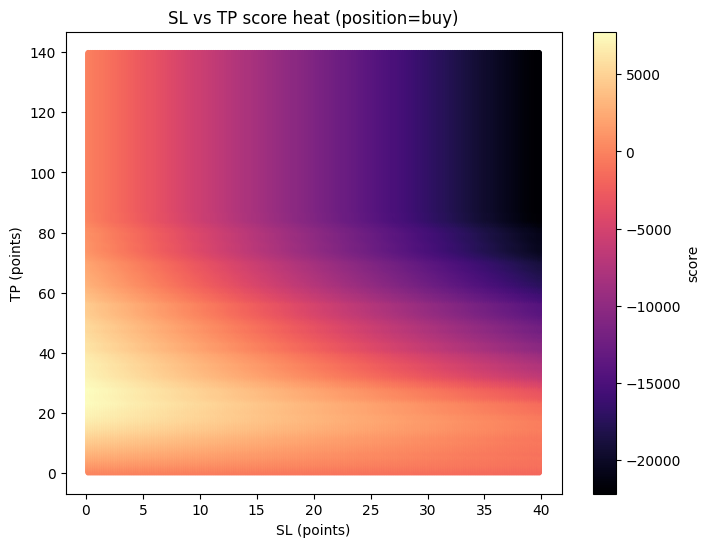

total number of tested SL/TP combos: 139101


In [7]:
#point interval = calculation granularity/speed


trade_type_settings = {
    'XAUUSD': {'sl': 40, 'tp': 140, 'spread': 0.2, 'point_interval': 0.2, 'round_points': 2, 'threshold': -4000},
    'GBPJPY': {'sl': 0.5, 'tp': 7, 'spread': 0.03, 'point_interval': 0.02, 'round_points': 4, 'threshold': -600},
    'EURNZD': {'sl': 0.00900, 'tp': 0.01800, 'spread': 0.00050, 'point_interval': 0.00020, 'round_points': 6, 'threshold': -1000}
}

settings = trade_type_settings.get(trade_type)

sl = settings['sl']
tp = settings['tp']
spread = settings['spread']
point_interval = settings['point_interval']

# preview exact counts:
s_count, t_count, total = count_combinations(spread, sl, tp, point_interval)
print(f"Will test {s_count} SL steps × {t_count} TP steps = {total} combos")

# run with a progress bar (tqdm if available)
results_buy = sl_tp_with_progress(buy_df, 'buy',
                                 sl=sl, tp=tp,
                                 spread=spread, point_interval=point_interval,
                                 breakeven_after=0.0,
                                 tie_breaker='tp',
                                 show_progress=True)

In [14]:
SL_FILTER = 3.0

filtered_df = output_df[np.isclose(output_df['SL'], SL_FILTER)]
top8 = filtered_df.nlargest(8, 'score')

print(top8)

#display(output_df.nlargest(8, 'score'))
#display(output_df.nlargest(8, 'win_pos'))
#display(output_df.nlargest(8, 'TP'))

#Optimal outcome:

#GBPJPY 0.15 SL, 5.89 TP -56.81 score 2.37(196/8271)% win rate (holding position for a month, long on green)
#Gold 0.6 SL, 83.6 TP -266.0 score 0.673(53/7881)% win rate (holding position for a month, long on green)

       score   SL    TP  win_pos  all_pos   win_rate
9903  7080.4  3.0  23.6      329      557  59.066427
9904  7065.8  3.0  23.8      326      557  58.527828
9905  7050.0  3.0  24.0      323      557  57.989228
9902  7041.0  3.0  23.4      330      557  59.245961
9906  7005.8  3.0  24.2      319      557  57.271095
9901  7001.2  3.0  23.2      331      557  59.425494
9907  6987.4  3.0  24.4      316      557  56.732496
9924  6983.8  3.0  27.8      281      557  50.448833


In [13]:
print('total length of output dataframe :' + str(len(output_df)))

total length of output dataframe :139101


In [19]:
# ---------- Filter + Metrics + Cleaner 3D Plot ----------
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# user-config
SL_THRESHOLD = 3.5            # change this to any minimum SL you want
TOP_N = 8
round_points = globals().get('round_points', 2)

# defensive copy
df = output_df.copy()

# ensure numeric
for c in ['score', 'SL', 'TP', 'win_pos', 'all_pos', 'win_rate']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# derived metrics (same as before)
df['num_losses'] = df['all_pos'] - df['win_pos']
df['total_win_points'] = df['win_pos'] * df['TP']
df['total_loss_points'] = df['num_losses'] * df['SL']
df['EV_per_trade'] = (df['total_win_points'] - df['total_loss_points']) / df['all_pos'].replace(0, np.nan)
df['score_per_trade'] = df['score'] / df['all_pos'].replace(0, np.nan)
df['profit_factor'] = df['total_win_points'] / df['total_loss_points'].replace(0, np.nan)
df['win_rate_display'] = df['win_rate'].round(2)

# filter by SL threshold
df_filtered = df[df['SL'] >= SL_THRESHOLD].copy()
print(f"Total combos before filter: {len(df)}, after SL>={SL_THRESHOLD}: {len(df_filtered)}")

# TOP lists
top_by_score = df_filtered.nlargest(TOP_N, 'score')
top_by_ev = df_filtered.nlargest(TOP_N, 'EV_per_trade')

def nice_display(tab, title):
    cols = ['score','SL','TP','win_pos','all_pos','win_rate_display','EV_per_trade','profit_factor']
    dd = tab[cols].copy()
    dd['score'] = dd['score'].round(2)
    dd['SL'] = dd['SL'].round(round_points)
    dd['TP'] = dd['TP'].round(round_points)
    dd['EV_per_trade'] = dd['EV_per_trade'].round(4)
    dd['profit_factor'] = dd['profit_factor'].round(3)
    print("\n" + title)
    print(dd.to_string(index=False))

nice_display(top_by_score, f"Top {TOP_N} (by SCORE) with SL >= {SL_THRESHOLD}")
nice_display(top_by_ev,    f"Top {TOP_N} (by EV_per_trade) with SL >= {SL_THRESHOLD}")

# ------------ 3D plot: SL (x), TP (y), EV_per_trade (z) ------------
plot_df = df_filtered.copy()

# color by EV_per_trade but clip extremes to 2nd/98th percentile to avoid whitewashed gradient
vmin = plot_df['EV_per_trade'].quantile(0.02)
vmax = plot_df['EV_per_trade'].quantile(0.98)

# optional: if vmin==vmax (flat), expand slightly
if np.isclose(vmin, vmax):
    vmin -= 1e-6
    vmax += 1e-6

hover_text = (
    "SL: " + plot_df['SL'].round(round_points).astype(str) + "<br>" +
    "TP: " + plot_df['TP'].round(round_points).astype(str) + "<br>" +
    "Score: " + plot_df['score'].round(2).astype(str) + "<br>" +
    "EV/trade: " + plot_df['EV_per_trade'].round(4).astype(str) + "<br>" +
    "WinRate: " + plot_df['win_rate'].round(2).astype(str) + "%<br>" +
    "All trades: " + plot_df['all_pos'].astype(int).astype(str)
)

# marker size scaling: base + scale by number of trades (cap for visual sanity)
size_base = 6
size_scale = 10
sizes = size_base + (plot_df['all_pos'] / plot_df['all_pos'].max()).fillna(0) * size_scale
sizes = sizes.clip(lower=3, upper=20)

fig = go.Figure(data=go.Scatter3d(
    x=plot_df['SL'],
    y=plot_df['TP'],
    z=plot_df['EV_per_trade'],
    mode='markers',
    marker=dict(
        size=sizes,
        color=plot_df['EV_per_trade'],
        colorscale='Turbo',
        cmin=vmin,
        cmax=vmax,
        colorbar=dict(title='EV/trade'),
        opacity=0.7
    ),
    hovertext=hover_text,
    hoverinfo='text'
))

fig.update_layout(
    title=f'SL>= {SL_THRESHOLD}: SL vs TP vs EV_per_trade',
    scene=dict(xaxis=dict(title='SL'), yaxis=dict(title='TP'), zaxis=dict(title='EV per trade')),
    height=700
)

# Save and try to open in browser (reliable)
html_path = f"sl_tp_3d_SLge{SL_THRESHOLD}.html"
fig.write_html(html_path, include_plotlyjs='cdn')
print(f"Interactive 3D plot saved: {html_path}")

# try to open in browser
try:
    pio.renderers.default = "browser"
    fig.show()
except Exception as e:
    print("Could not auto-open in browser; plot saved to HTML. Error:", e)

Total combos before filter: 139101, after SL>=3.5: 127218

Top 8 (by SCORE) with SL >= 3.5
 score  SL   TP  win_pos  all_pos  win_rate_display  EV_per_trade  profit_factor
6943.6 3.6 23.6      329      557             59.07       12.4661          9.460
6927.2 3.6 23.8      326      557             58.53       12.4366          9.330
6909.6 3.6 24.0      323      557             57.99       12.4050          9.202
6904.8 3.6 23.4      330      557             59.25       12.3964          9.449
6898.0 3.8 23.6      329      557             59.07       12.3842          8.962
6881.0 3.8 23.8      326      557             58.53       12.3537          8.839
6865.6 3.6 23.2      331      557             59.43       12.3260          9.439
6863.0 3.6 24.2      319      557             57.27       12.3214          9.010

Top 8 (by EV_per_trade) with SL >= 3.5
 score  SL   TP  win_pos  all_pos  win_rate_display  EV_per_trade  profit_factor
6943.6 3.6 23.6      329      557             59.07       1

In [18]:
test_sl = round(output_df.nlargest(1, 'score').iloc[0][1], 2)
test_tp = round(output_df.nlargest(1, 'score').iloc[0][2], 2)


buy_df = buy_df[(buy_df['cs_color'] == 'green')]


buy_df['Result'] = np.where(
    ((buy_df['close'] - buy_df['next_min'] <= test_sl - spread) & 
     (buy_df['next_max'] - buy_df['close'] > test_tp + spread) & 
     (buy_df['next_max_time'] > buy_df['next_min_time'])), 
    1, 
    np.where(
        (buy_df['close'] - buy_df['next_min'] > test_tp - spread), 
        0, 0
    )
)

buy_df_good = buy_df[buy_df['Result'] == 1]
bad = len(buy_df[buy_df['Result'] == 0])
df_good = buy_df[(buy_df['Result'] == 1)]
df_bad = buy_df[(buy_df['Result'] == 0)]


print('SL used for test : ' + str(test_sl))
print('TP used for test : ' + str(test_tp))
display(len(buy_df_good))
display(buy_df_good.head())

SL used for test : 0.2
TP used for test : 27.8


C:\Users\loong\AppData\Local\Temp\ipykernel_3452\3198105559.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\loong\AppData\Local\Temp\ipykernel_3452\3198105559.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



0

,time,open,high,low,close,MA_5min,MA_hour,MA_day,MA_week,next_min,next_max,next_min_unique,next_max_unique,next_min_time,next_max_time,%K,%D,%DSlow,breakout_strength,trend_label,cs_color,position_type,Result


In [20]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd

def visualize_(positions_df, df_hour_local=None, df2=None,
               ma_lines=('MA_day','MA_week'), height=600,
               html_filename="positions_plot.html", open_in_browser=True):
    """
    Visualize hourly price (from df_hour_local) and overlay position markers.

    Args:
      positions_df: DataFrame of candidate positions (must contain 'time', 'close', 'Result', 'position_type' preferably)
      df_hour_local: DataFrame of H1 prices. If None, function will look for global `df_hour`.
      df2: optional second positions DataFrame to overlay.
      ma_lines: tuple of MA column names to plot if present (e.g. 'MA_hour','MA_day','MA_week').
      height: figure height in pixels.
      html_filename: fallback filename to save interactive HTML.
      open_in_browser: attempt to open in default browser (safe fallback).
    """

    # --- Resolve hourly price dataframe ---
    if df_hour_local is None:
        if 'df_hour' in globals():
            df_hour_local = globals()['df_hour']
        else:
            raise ValueError("df_hour_local not provided and global df_hour not found.")

    # Defensive copy & ensure datetime
    df_h = df_hour_local.copy()
    for c in ['time']:
        if c in df_h.columns:
            df_h[c] = pd.to_datetime(df_h[c], errors='coerce')

    pos = positions_df.copy()
    pos['time'] = pd.to_datetime(pos['time'], errors='coerce')

    if isinstance(df2, pd.DataFrame):
        pos2 = df2.copy()
        pos2['time'] = pd.to_datetime(pos2['time'], errors='coerce')
    else:
        pos2 = None

    # --- Build base price traces ---
    fig_base = go.Figure()

    fig_base.add_trace(
        go.Scatter(
            x=df_h['time'],
            y=df_h['close'],
            mode='lines',
            name='Price',
            line=dict(width=1),
            hoverinfo='x+y'
        )
    )

    # Add MA lines if present and requested
    for ma in ma_lines:
        if ma in df_h.columns:
            fig_base.add_trace(
                go.Scatter(
                    x=df_h['time'],
                    y=df_h[ma],
                    mode='lines',
                    name=ma,
                    line=dict(width=1, dash='dash'),
                    hoverinfo='skip'
                )
            )

    # --- Helper to create scatter trace via px (colors by Result) then extract traces ---
    def px_scatter_traces(df_scatter, name_prefix="positions"):
        """
        Use plotly.express to color by 'Result' (categorical) and produce traces list.
        Returns list of traces.
        """
        # build hover_data: include some helpful fields if present
        hover_fields = []
        for f in ['position_type', 'Result', 'next_min', 'next_max', 'next_min_time', 'next_max_time']:
            if f in df_scatter.columns:
                hover_fields.append(f)

        fig_px = px.scatter(
            df_scatter,
            x='time',
            y='close',
            color=df_scatter['Result'].astype(str) if 'Result' in df_scatter.columns else None,
            hover_data=hover_fields,
            labels={'color':'Result'},
            title=None
        )

        # optionally rename traces for clarity
        for t in fig_px.data:
            t.name = f"{name_prefix} · {t.name}"
            t.hovertemplate = t.hovertemplate  # keep default but it's fine
        return fig_px.data

    # --- Position traces ---
    pos_traces = px_scatter_traces(pos, name_prefix="pos")
    fig_traces = list(fig_base.data) + list(pos_traces)

    if pos2 is not None:
        pos2_traces = px_scatter_traces(pos2, name_prefix="pos2")
        fig_traces += list(pos2_traces)

    fig = go.Figure(data=fig_traces)

    fig.update_layout(
        height=height,
        legend=dict(title="Legend"),
        margin=dict(l=40, r=20, t=40, b=40)
    )

    # Print counts (useful feedback)
    count_msg = f"Quantity of positions plotted: {len(pos)}" + (f" + {len(pos2)} (second set)" if pos2 is not None else "")
    print(count_msg)

    # --- Safe rendering: try to show in browser, otherwise save HTML ---
    try:
        # prefer opening in a browser window (avoids nbformat issues)
        if open_in_browser:
            pio.renderers.default = "browser"
            fig.show()
        else:
            # fallback to saving HTML
            fig.write_html(html_filename, include_plotlyjs='cdn')
            print(f"Saved interactive plot to {html_filename}")
    except Exception as e:
        # final fallback: always write HTML
        fig.write_html(html_filename, include_plotlyjs='cdn')
        print(f"Could not render inline (error: {e}). Saved interactive plot to: {html_filename}")

    return fig

In [21]:
# 1) plot positions (single set) using global df_hour
fig = visualize_(buy_df)                       # if buy_df exists

# 2) plot two sets (buy_df + sell_df)
#fig = visualize_(buy_df, df2=sell_df)

# 3) pass a different hourly dataframe explicitly
#fig = visualize_(buy_df, df_hour_local=df_hour)

Quantity of positions plotted: 7881
